<a href="https://colab.research.google.com/github/pritishma-shakya/ai-and-machine-learning/blob/main/PritishmaShakya_2408412_Worksheet4_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


6. Exercise: Building a Fully Connected Network (FCN) for
Devnagari Digit Classification.

Task 1: Data Preparation
Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image.

Hints:

• Ensure that the images are resized to a consistent shape (e.g., 28x28).

• Convert labels to one-hot encoded format for multi-class classification.

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


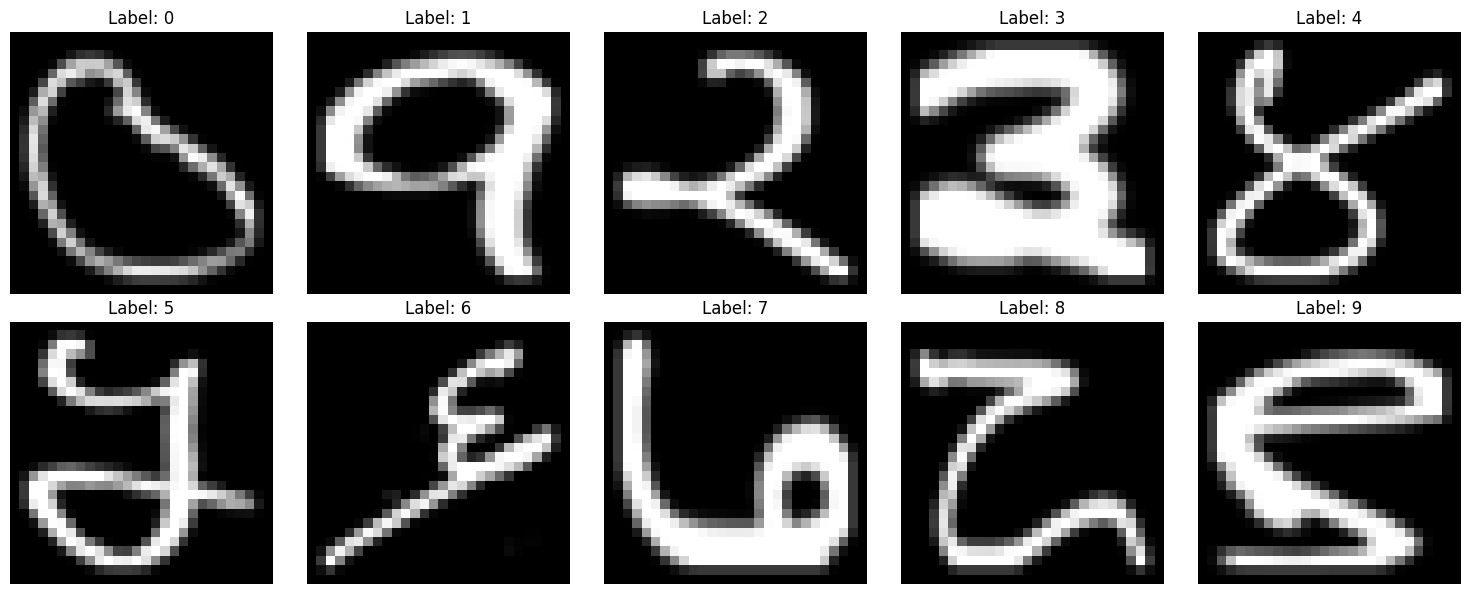

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/Sem6AI/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "/content/drive/MyDrive/Sem6AI/DevanagariHandwrittenDigitDataset/Test/"

# Define image size
img_height, img_width = 28, 28
# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
    class_path = os.path.join(folder, class_name)
    if not os.path.isdir(class_path):
      continue
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)

      # Load image using PIL
      img = Image.open(img_path).convert("L") # Convert to grayscale
      img = img.resize((img_width, img_height)) # Resize to (28,28)
      img = np.array(img) / 255.0 # Normalize pixel values to [0,1]

      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)
# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)
# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")
# Visualize some images
# Show one sample image per class (digit 0-9)
unique_indices = [np.where(np.argmax(y_train, axis=1) == i)[0][0] for i in range(10)]

plt.figure(figsize=(15, 6))
for i, idx in enumerate(unique_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {i}', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

Task 2: Build the FCN Model
Model Architecture

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:

  – 1st hidden layer: 64 neurons

  – 2nd hidden layer: 128 neurons

  – 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [ ]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
  [
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
  ]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3: Compile the Model Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy), and evaluation metric (e.g., accuracy).

In [ ]:
model.compile(
  optimizer="adam", # Stochastic Gradient Descent
  loss="categorical_crossentropy", # Loss function for multi-class classification
  metrics=["accuracy"] # Track accuracy during training
)

Task 4: Train the Model
Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.

• Use validation split (validation split=0.2) to monitor the model’s performance on validation
data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [ ]:
# Shuffle training data to remove ordered-label bias (0-9 sequence)
indices = np.arange(x_train.shape[0])
np.random.shuffle(indices)
x_train = x_train[indices]
y_train = y_train[indices]

In [ ]:
batch_size = 128
epochs = 20

callbacks = [
  keras.callbacks.ModelCheckpoint(filepath='model_at_epoch_{epoch}.keras'),
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=4),
]

history = model.fit(
  x_train,
  y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_split=0.2,
  callbacks=callbacks,
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4143 - loss: 1.8753 - val_accuracy: 0.7494 - val_loss: 1.0601
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8042 - loss: 0.6695 - val_accuracy: 0.8688 - val_loss: 0.4504
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8828 - loss: 0.3774 - val_accuracy: 0.9206 - val_loss: 0.2994
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9252 - loss: 0.2603 - val_accuracy: 0.9335 - val_loss: 0.2258
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9454 - loss: 0.1934 - val_accuracy: 0.9518 - val_loss: 0.1749
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9584 - loss: 0.1503 - val_accuracy: 0.9550 - val_loss: 0.1579
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9672 - loss: 0.1217 - val_accuracy: 0.9612 - val_loss: 0.1345
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9743 - loss: 0.0996 - val_accuracy:

Task 5: Evaluate the Model
Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.9797 - loss: 0.0766
Test accuracy: 0.9797
Test loss: 0.0766


Task 6: Save and Load the Model

Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [ ]:
# Save model (modern format)
model.save('devnagari_model.h5')

# Load model
loaded_model = tf.keras.models.load_model('devnagari_model.h5')

# Evaluate
loss, acc = loaded_model.evaluate(x_test, y_test)
print(f'Re-evaluated Accuracy: {acc:.4f}')

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9797 - loss: 0.0766
Re-evaluated Accuracy: 0.9797


Task 7: Predictions
Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


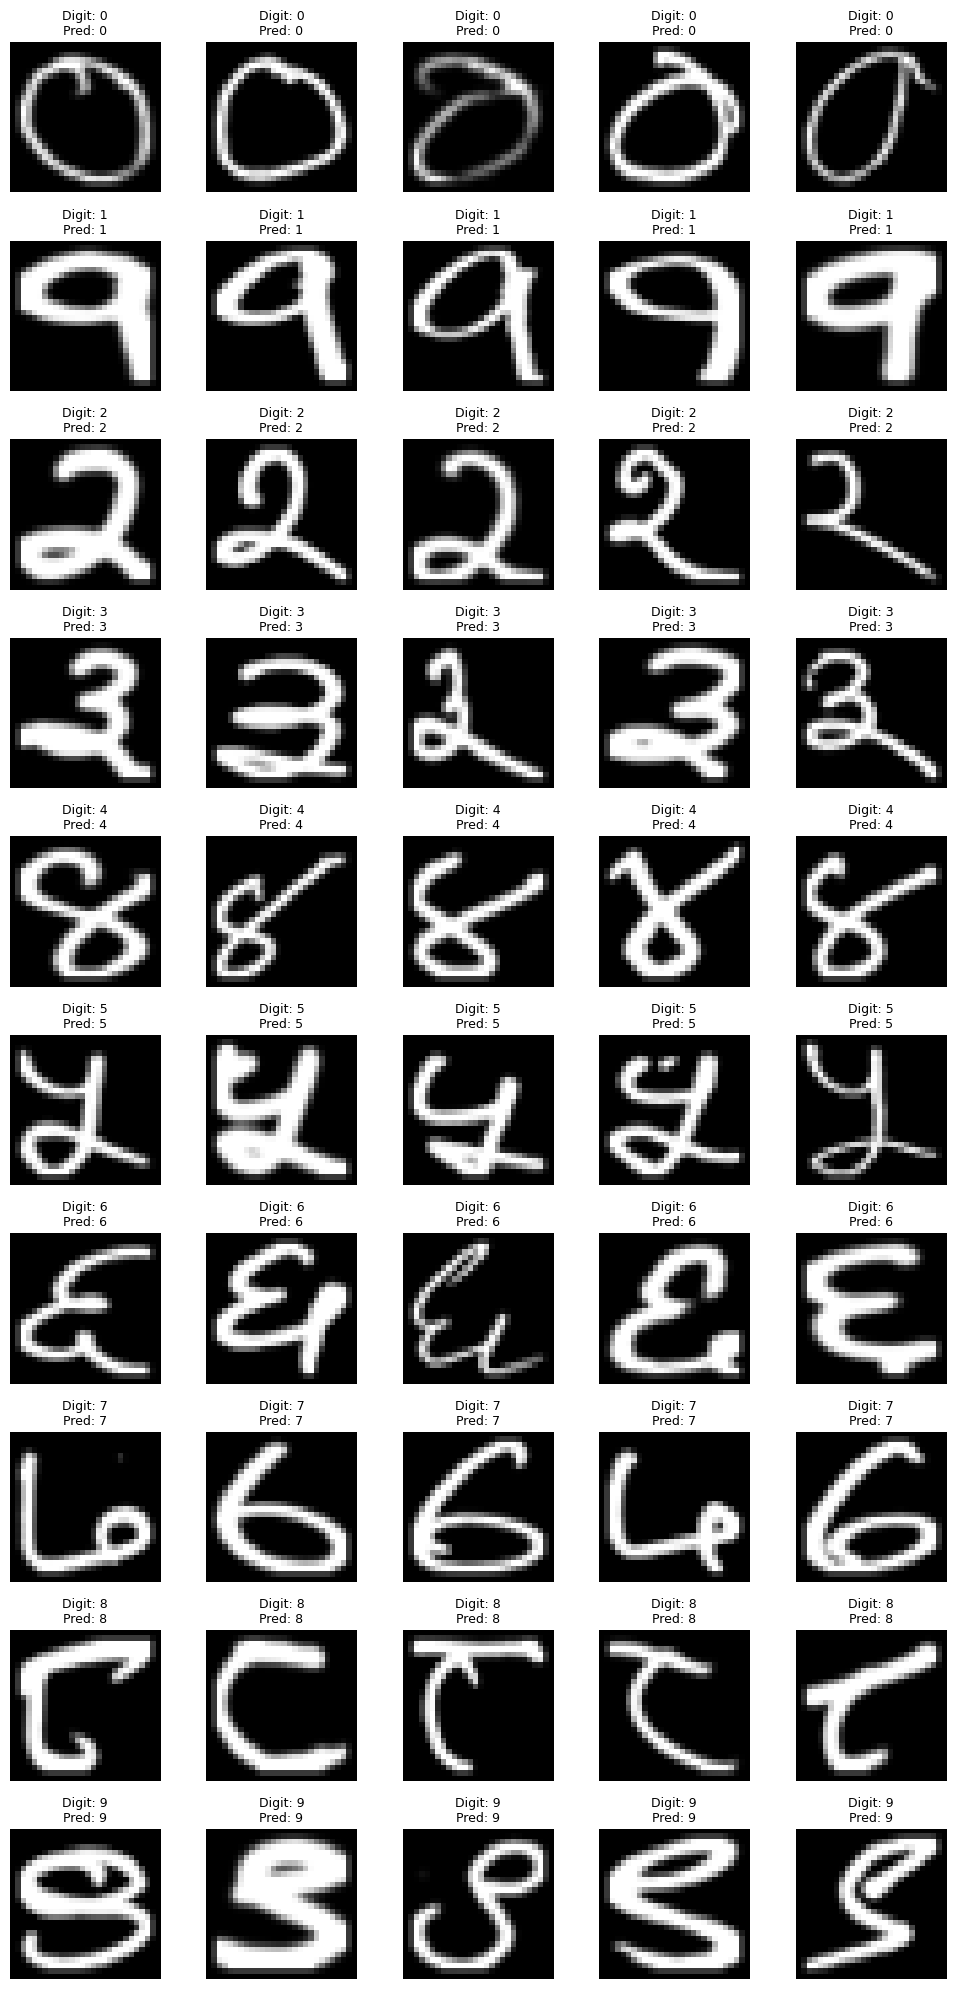

In [11]:
import matplotlib.pyplot as plt
import numpy as np

y_test_integers   = np.argmax(y_test, axis=1)
predictions_ints  = np.argmax(loaded_model.predict(x_test), axis=1)

# Show 5 examples for each digit: 10 rows x 5 columns
plt.figure(figsize=(10, 20))
for i in range(10):
    idxs = np.where(y_test_integers == i)[0]
    for j in range(5):
        if j < len(idxs):
            idx = idxs[j]
            plt.subplot(10, 5, i * 5 + j + 1)
            plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
            plt.title(f'Digit: {i}\nPred: {predictions_ints[idx]}', fontsize=9)
            plt.axis('off')

plt.tight_layout()
plt.show()